# 05. Modelos de machine learning

- `ridge`
- `decision_tree`
- `random_forest`
- `hist_gradient_boosting`
- `xgboost`
- `lightgbm`
- `catboost`

In [ ]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["BLIS_NUM_THREADS"] = "1"

print("Límites de hilos configurados.")

Límites de hilos configurados.


In [ ]:
# =============================================================================
# 1. CONFIGURACIÓN DE LA EJECUCIÓN
# =============================================================================

#MODEL_TO_RUN = "ridge"
#MODEL_TO_RUN = "decision_tree"
#MODEL_TO_RUN = "random_forest"
#MODEL_TO_RUN = "hist_gradient_boosting"
#MODEL_TO_RUN = "xgboost"
MODEL_TO_RUN = "lightgbm"
#MODEL_TO_RUN = "catboost"

DEVELOPMENT_TRAIN_DAYS = 90

N_JOBS = 1

RANDOM_STATE = 42

VALID_MODELS = {
    "ridge",
    "decision_tree",
    "random_forest",
    "hist_gradient_boosting",
    "xgboost",
    "lightgbm",
    "catboost",
}

if MODEL_TO_RUN not in VALID_MODELS:
    raise ValueError(
        f"MODEL_TO_RUN debe ser uno de estos valores: {sorted(VALID_MODELS)}"
    )

print(f"Modelo seleccionado: {MODEL_TO_RUN}")
print(f"Ventana de entrenamiento: {DEVELOPMENT_TRAIN_DAYS} días")
print(f"Hilos: {N_JOBS}")

Modelo seleccionado: lightgbm
Ventana de entrenamiento: 90 días
Hilos: 1


In [ ]:
# =============================================================================
# 2. IMPORTACIONES MÍNIMAS Y CONDICIONALES
# =============================================================================

import gc
import json
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_log_error,
    root_mean_squared_error,
)
from sklearn.pipeline import Pipeline

if MODEL_TO_RUN == "ridge":
    from sklearn.linear_model import Ridge
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

elif MODEL_TO_RUN == "decision_tree":
    from sklearn.preprocessing import OrdinalEncoder
    from sklearn.tree import DecisionTreeRegressor

elif MODEL_TO_RUN == "random_forest":
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.preprocessing import OrdinalEncoder

elif MODEL_TO_RUN == "hist_gradient_boosting":
    from sklearn.ensemble import HistGradientBoostingRegressor
    from sklearn.preprocessing import OrdinalEncoder

elif MODEL_TO_RUN == "xgboost":
    from sklearn.preprocessing import OrdinalEncoder
    from xgboost import XGBRegressor

elif MODEL_TO_RUN == "lightgbm":
    from sklearn.preprocessing import OrdinalEncoder
    from lightgbm import LGBMRegressor

elif MODEL_TO_RUN == "catboost":
    from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

print("Importaciones correctas.")

Importaciones correctas.


In [37]:
# =============================================================================
# 3. RUTAS
# =============================================================================

PROJECT_ROOT = Path("..")

PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"
RESULTS_DATA_PATH = PROJECT_ROOT / "data" / "results"
MODELS_PATH = PROJECT_ROOT / "models"

RESULTS_DATA_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)

DATASET_PATH = PROCESSED_DATA_PATH / "train_prepared.parquet"
SPLIT_PATH = PROCESSED_DATA_PATH / "temporal_split_dates.csv"

RESULTS_PATH = RESULTS_DATA_PATH / "machine_learning_validation_results.csv"
BASELINE_RESULTS_PATH = RESULTS_DATA_PATH / "baseline_validation_results.csv"

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"No se encuentra: {DATASET_PATH}")

if not SPLIT_PATH.exists():
    raise FileNotFoundError(f"No se encuentra: {SPLIT_PATH}")

print("Rutas comprobadas.")

# Carpeta para las figuras del notebook de modelos de Machine Learning.
ML_FIGURES_PATH = PROJECT_ROOT / "figures" / "05_modelos_ml"
ML_FIGURES_PATH.mkdir(parents=True, exist_ok=True)



Rutas comprobadas.


In [38]:
# =============================================================================
# 4. FUNCIONES AUXILIARES
# =============================================================================

def process_memory_gb():
    """Memoria RSS aproximada del proceso actual."""
    try:
        import psutil
        return psutil.Process().memory_info().rss / 1024**3
    except ImportError:
        return np.nan


def dataframe_memory_mb(df):
    """Memoria aproximada de un DataFrame en MB."""
    return df.memory_usage(deep=True).sum() / 1024**2


def calculate_metrics(y_true, y_pred):
    """Calcula RMSLE, MAE y RMSE."""
    y_true = np.asarray(y_true)
    y_pred = np.clip(np.asarray(y_pred), 0, None)

    return {
        "RMSLE": float(
            np.sqrt(mean_squared_log_error(y_true, y_pred))
        ),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(root_mean_squared_error(y_true, y_pred)),
    }


def get_split_dates(split_table, partition):
    """Devuelve fecha inicial y final de una partición."""
    selected = split_table.loc[
        split_table["partition"] == partition
    ]

    if selected.empty:
        raise ValueError(f"No existe la partición: {partition}")

    row = selected.iloc[0]
    return row["start_date"], row["end_date"]


def upsert_result(result, results_path):
    """
    Añade o actualiza una ejecución.

    Se considera única la combinación:
    modelo + ventana de entrenamiento.
    """
    new_row = pd.DataFrame([result])

    if results_path.exists():
        previous = pd.read_csv(results_path)
        combined = pd.concat([previous, new_row], ignore_index=True)
    else:
        combined = new_row

    combined = (
        combined
        .drop_duplicates(
            subset=["model", "development_train_days"],
            keep="last",
        )
        .sort_values(
            ["development_train_days", "RMSLE"],
            na_position="last",
        )
        .reset_index(drop=True)
    )

    combined.to_csv(results_path, index=False)
    return combined


def save_predictions(identifiers, predictions, model_name, train_days):
    """Guarda las predicciones de validación de una ejecución."""
    output = identifiers.copy()
    output["prediction"] = np.asarray(predictions, dtype=np.float32)

    window_label = "all" if train_days is None else str(train_days)

    path = (
        RESULTS_DATA_PATH
        / f"predictions_{model_name}_{window_label}d.parquet"
    )

    output.to_parquet(path, index=False)
    return path


print(f"Memoria inicial: {process_memory_gb():.2f} GB")

Memoria inicial: 0.65 GB


In [39]:
# =============================================================================
# 5. FECHAS DE DIVISIÓN
# =============================================================================

split_dates = pd.read_csv(
    SPLIT_PATH,
    parse_dates=["start_date", "end_date"],
)

train_start, train_end = get_split_dates(split_dates, "train")
validation_start, validation_end = get_split_dates(
    split_dates,
    "validation",
)
test_start, test_end = get_split_dates(split_dates, "test")

if DEVELOPMENT_TRAIN_DAYS is None:
    effective_train_start = train_start
else:
    candidate_start = (
        train_end
        - pd.Timedelta(days=DEVELOPMENT_TRAIN_DAYS - 1)
    )
    effective_train_start = max(train_start, candidate_start)

print(
    f"Entrenamiento efectivo: {effective_train_start.date()} "
    f"- {train_end.date()}"
)
print(
    f"Validación: {validation_start.date()} "
    f"- {validation_end.date()}"
)
print(
    f"Test reservado: {test_start.date()} "
    f"- {test_end.date()}"
)

Entrenamiento efectivo: 2017-03-23 - 2017-06-20
Validación: 2017-06-21 - 2017-07-18
Test reservado: 2017-07-19 - 2017-08-15


## Selección de variables

In [ ]:
# =============================================================================
# 6. VARIABLES DEL MODELO
# =============================================================================

TARGET = "sales"

candidate_features = [
    "store_nbr",
    "family",
    "city",
    "state",
    "type",
    "cluster",
    "onpromotion",
    "oil_price",

    # Festivos
    "is_national_holiday",
    "is_regional_holiday",
    "is_local_holiday",
    "is_holiday",
    "is_extra_work_day",

    # Historial de transacciones
    "transactions_lag_1",
    "transactions_lag_7",
    "transactions_rolling_mean_7",
    "transactions_rolling_mean_28",

    # Historial de ventas
    "sales_lag_1",
    "sales_lag_7",
    "sales_lag_14",
    "sales_lag_28",
    "sales_rolling_mean_7",
    "sales_rolling_mean_14",
    "sales_rolling_mean_28",

    # Calendario
    "year",
    "month",
    "day",
    "day_of_week",
    "day_of_year",
    "week_of_year",
    "quarter",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "is_quarter_start",
    "is_quarter_end",
    "time_index",

    # Variables cíclicas
    "month_sin",
    "month_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "day_of_year_sin",
    "day_of_year_cos",
]
parquet_columns = pd.read_parquet(
    DATASET_PATH,
    columns=[],
).columns.tolist()

if not parquet_columns:
    import pyarrow.parquet as pq
    parquet_columns = pq.read_schema(DATASET_PATH).names

feature_columns = [
    column
    for column in candidate_features
    if column in parquet_columns
]

missing_features = [
    column
    for column in candidate_features
    if column not in parquet_columns
]

required_columns = [
    "date",
    TARGET,
    *feature_columns,
]

required_columns = list(dict.fromkeys(required_columns))

categorical_features = [
    column
    for column in [
        "store_nbr",
        "family",
        "city",
        "state",
        "type",
        "cluster",
        "month",
        "day_of_week",
        "quarter",
    ]
    if column in feature_columns
]

numeric_features = [
    column
    for column in feature_columns
    if column not in categorical_features
]

print(f"Variables utilizadas: {len(feature_columns)}")
print("Variables categóricas:", categorical_features)
print("Variables no disponibles:", missing_features)

Variables utilizadas: 43
Variables categóricas: ['store_nbr', 'family', 'city', 'state', 'type', 'cluster', 'month', 'day_of_week', 'quarter']
Variables no disponibles: []


In [41]:
sales_features_used = [
    column
    for column in feature_columns
    if column.startswith("sales_")
]

print("Variables históricas de ventas utilizadas:")
print(sales_features_used)

assert len(sales_features_used) == 7, (
    "No se están incorporando todas las variables históricas de ventas."
)

Variables históricas de ventas utilizadas:
['sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'sales_rolling_mean_7', 'sales_rolling_mean_14', 'sales_rolling_mean_28']


In [ ]:
# =============================================================================
# 7. CARGA FILTRADA DEL PARQUET
# =============================================================================

load_start = effective_train_start
load_end = validation_end

filters = [
    ("date", ">=", load_start),
    ("date", "<=", load_end),
]

try:
    df = pd.read_parquet(
        DATASET_PATH,
        columns=required_columns,
        filters=filters,
        engine="pyarrow",
    )
    filter_applied_during_read = True

except Exception as error:
    print(
        "No se pudo aplicar el filtro durante la lectura. "
        "Se usará lectura por columnas y filtrado posterior."
    )
    print("Detalle:", error)

    df = pd.read_parquet(
        DATASET_PATH,
        columns=required_columns,
        engine="pyarrow",
    )

    filter_applied_during_read = False

df["date"] = pd.to_datetime(df["date"])


df = df.loc[
    (df["date"] >= load_start)
    & (df["date"] <= load_end)
].reset_index(drop=True)

print("Filtro aplicado durante lectura:", filter_applied_during_read)
print("Dimensiones cargadas:", df.shape)
print(f"Memoria del DataFrame: {dataframe_memory_mb(df):.2f} MB")
print(f"Memoria del proceso: {process_memory_gb():.2f} GB")

Filtro aplicado durante lectura: True
Dimensiones cargadas: (210276, 45)
Memoria del DataFrame: 28.08 MB
Memoria del proceso: 0.68 GB


In [ ]:
# =============================================================================
# 8. CREACIÓN DE MATRICES
# =============================================================================

train_mask = (
    (df["date"] >= effective_train_start)
    & (df["date"] <= train_end)
)

validation_mask = (
    (df["date"] >= validation_start)
    & (df["date"] <= validation_end)
)

validation_identifiers = (
    df.loc[
        validation_mask,
        ["date", "store_nbr", "family", TARGET],
    ]
    .reset_index(drop=True)
    .copy()
)

X_train = (
    df.loc[train_mask, feature_columns]
    .reset_index(drop=True)
    .copy()
)

y_train = (
    df.loc[train_mask, TARGET]
    .reset_index(drop=True)
    .astype(np.float32)
)

X_validation = (
    df.loc[validation_mask, feature_columns]
    .reset_index(drop=True)
    .copy()
)

y_validation = (
    df.loc[validation_mask, TARGET]
    .reset_index(drop=True)
    .astype(np.float32)
)

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print(f"Memoria X_train: {dataframe_memory_mb(X_train):.2f} MB")
print(f"Memoria X_validation: {dataframe_memory_mb(X_validation):.2f} MB")

del df
del train_mask
del validation_mask
gc.collect()

print(f"Memoria tras liberar df: {process_memory_gb():.2f} GB")

X_train: (160380, 43)
X_validation: (49896, 43)
Memoria X_train: 19.58 MB
Memoria X_validation: 6.10 MB
Memoria tras liberar df: 0.68 GB


In [44]:
print(
    "Variables históricas presentes en X_train:",
    [
        column
        for column in X_train.columns
        if column.startswith("sales_")
    ]
)

Variables históricas presentes en X_train: ['sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'sales_rolling_mean_7', 'sales_rolling_mean_14', 'sales_rolling_mean_28']


In [45]:
# =============================================================================
# 9. PREPROCESADOR NECESARIO PARA EL MODELO SELECCIONADO
# =============================================================================

preprocessor = None

if MODEL_TO_RUN == "ridge":

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    steps=[
                        (
                            "imputer",
                            SimpleImputer(strategy="median"),
                        ),
                        (
                            "scaler",
                            StandardScaler(with_mean=False),
                        ),
                    ]
                ),
                numeric_features,
            ),
            (
                "categorical",
                Pipeline(
                    steps=[
                        (
                            "imputer",
                            SimpleImputer(strategy="most_frequent"),
                        ),
                        (
                            "onehot",
                            OneHotEncoder(
                                handle_unknown="ignore",
                                sparse_output=True,
                                dtype=np.float32,
                            ),
                        ),
                    ]
                ),
                categorical_features,
            ),
        ],
        remainder="drop",
        sparse_threshold=1.0,
    )

elif MODEL_TO_RUN in {
    "decision_tree",
    "random_forest",
    "hist_gradient_boosting",
    "xgboost",
    "lightgbm",
}:

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    steps=[
                        (
                            "imputer",
                            SimpleImputer(strategy="median"),
                        ),
                    ]
                ),
                numeric_features,
            ),
            (
                "categorical",
                Pipeline(
                    steps=[
                        (
                            "imputer",
                            SimpleImputer(strategy="most_frequent"),
                        ),
                        (
                            "ordinal",
                            OrdinalEncoder(
                                handle_unknown="use_encoded_value",
                                unknown_value=-1,
                                dtype=np.float32,
                            ),
                        ),
                    ]
                ),
                categorical_features,
            ),
        ],
        remainder="drop",
    )

print("Preprocesador preparado.")

Preprocesador preparado.


## Entrenamiento

In [ ]:
# =============================================================================
# 10. ENTRENAMIENTO DEL MODELO SELECCIONADO
# =============================================================================

model = None
predictions = None
model_parameters = {}
training_start = time.time()

y_train_model = np.log1p(
    y_train.to_numpy(dtype=np.float32)
)

y_validation_model = np.log1p(
    y_validation.to_numpy(dtype=np.float32)
)

# -----------------------------------------------------------------------------
# RIDGE
# -----------------------------------------------------------------------------
if MODEL_TO_RUN == "ridge":

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                Ridge(
                    alpha=10.0,
                    solver="lsqr",
                    max_iter=500,
                    tol=1e-3,
                ),
            ),
        ]
    )

    model_parameters = {
        "alpha": 10.0,
        "solver": "lsqr",
        "max_iter": 500,
        "tol": 1e-3,
        "target_transform": "log1p",
    }

    model.fit(X_train, y_train_model)

    predictions = np.expm1(
        model.predict(X_validation)
    )

# -----------------------------------------------------------------------------
# MODELOS QUE NECESITAN CODIFICACIÓN ORDINAL
# -----------------------------------------------------------------------------
elif MODEL_TO_RUN in {
    "decision_tree",
    "random_forest",
    "hist_gradient_boosting",
    "xgboost",
    "lightgbm",
}:

    X_train_encoded = preprocessor.fit_transform(X_train)
    X_validation_encoded = preprocessor.transform(X_validation)

    # Evita una copia si la matriz ya es float32.
    X_train_encoded = np.asarray(
        X_train_encoded,
        dtype=np.float32,
    )
    X_validation_encoded = np.asarray(
        X_validation_encoded,
        dtype=np.float32,
    )

    print("Matriz codificada:", X_train_encoded.shape)
    print(
        f"Memoria matriz train: "
        f"{X_train_encoded.nbytes / 1024**2:.2f} MB"
    )

    if MODEL_TO_RUN == "decision_tree":

        model = DecisionTreeRegressor(
            max_depth=12,
            min_samples_leaf=100,
            random_state=RANDOM_STATE,
        )

        model_parameters = {
            "max_depth": 12,
            "min_samples_leaf": 100,
            "target_transform": "log1p",
        }

    elif MODEL_TO_RUN == "random_forest":

        model = RandomForestRegressor(
            n_estimators=20,
            max_depth=10,
            min_samples_leaf=100,
            max_features=0.70,
            max_samples=0.10,
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE,
            verbose=1,
        )

        model_parameters = {
            "n_estimators": 20,
            "max_depth": 10,
            "min_samples_leaf": 100,
            "max_features": 0.70,
            "max_samples": 0.10,
            "n_jobs": N_JOBS,
            "target_transform": "log1p",
        }

    elif MODEL_TO_RUN == "hist_gradient_boosting":

        model = HistGradientBoostingRegressor(
            learning_rate=0.08,
            max_iter=100,
            max_leaf_nodes=31,
            max_depth=8,
            min_samples_leaf=100,
            l2_regularization=1.0,
            early_stopping=True,
            validation_fraction=0.05,
            n_iter_no_change=10,
            random_state=RANDOM_STATE,
            verbose=1,
        )

        model_parameters = {
            "learning_rate": 0.08,
            "max_iter": 100,
            "max_leaf_nodes": 31,
            "max_depth": 8,
            "min_samples_leaf": 100,
            "l2_regularization": 1.0,
            "target_transform": "log1p",
        }

    elif MODEL_TO_RUN == "xgboost":

        model = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            min_child_weight=20,
            subsample=0.75,
            colsample_bytree=0.75,
            reg_alpha=0.10,
            reg_lambda=1.00,
            tree_method="hist",
            max_bin=128,
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE,
        )

        model_parameters = {
            "n_estimators": 200,
            "learning_rate": 0.05,
            "max_depth": 6,
            "min_child_weight": 20,
            "subsample": 0.75,
            "colsample_bytree": 0.75,
            "tree_method": "hist",
            "target_transform": "log1p",
        }

    elif MODEL_TO_RUN == "lightgbm":

        model = LGBMRegressor(
            objective="regression",
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=10,
            min_child_samples=100,
            subsample=0.75,
            colsample_bytree=0.75,
            reg_alpha=0.10,
            reg_lambda=1.00,
            max_bin=127,
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE,
            verbosity=-1,
        )

        model_parameters = {
            "n_estimators": 300,
            "learning_rate": 0.05,
            "num_leaves": 31,
            "max_depth": 10,
            "min_child_samples": 100,
            "subsample": 0.75,
            "colsample_bytree": 0.75,
            "target_transform": "log1p",
        }

    model.fit(
        X_train_encoded,
        y_train_model,
    )

    predictions = np.expm1(
        model.predict(X_validation_encoded)
    )

# -----------------------------------------------------------------------------
# CATBOOST CON CATEGORÍAS NATIVAS
# -----------------------------------------------------------------------------
elif MODEL_TO_RUN == "catboost":
    for column in categorical_features:
        X_train[column] = (
            X_train[column]
            .astype("object")
            .fillna("MISSING")
            .astype(str)
        )

        X_validation[column] = (
            X_validation[column]
            .astype("object")
            .fillna("MISSING")
            .astype(str)
        )

    categorical_indices = [
        X_train.columns.get_loc(column)
        for column in categorical_features
    ]

    model = CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        iterations=300,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=5.0,
        random_seed=RANDOM_STATE,
        verbose=50,
        allow_writing_files=False,
        thread_count=N_JOBS,
    )

    model_parameters = {
        "iterations": 300,
        "learning_rate": 0.05,
        "depth": 6,
        "l2_leaf_reg": 5.0,
        "thread_count": N_JOBS,
        "target_transform": "log1p",
    }

    model.fit(
        X_train,
        y_train_model,
        cat_features=categorical_indices,
        eval_set=(X_validation, y_validation_model),
        early_stopping_rounds=30,
        use_best_model=True,
    )

    predictions = np.expm1(
        model.predict(X_validation)
    )

else:
    raise ValueError(f"Modelo no reconocido: {MODEL_TO_RUN}")

training_seconds = time.time() - training_start

if predictions is None:
    raise RuntimeError(
        f"No se generaron predicciones para {MODEL_TO_RUN}"
    )

predictions = np.clip(
    predictions,
    0,
    None,
).astype(np.float32)

metrics = calculate_metrics(
    y_validation,
    predictions,
)

result = {
    "model": MODEL_TO_RUN,
    **metrics,
    "training_seconds": float(training_seconds),
    "train_rows": int(len(y_train)),
    "validation_rows": int(len(y_validation)),
    "train_start": effective_train_start.date().isoformat(),
    "train_end": train_end.date().isoformat(),
    "validation_start": validation_start.date().isoformat(),
    "validation_end": validation_end.date().isoformat(),
    "development_train_days": DEVELOPMENT_TRAIN_DAYS,
    "parameters": json.dumps(model_parameters),
}

display(pd.DataFrame([result]))

print(f"Memoria tras entrenar: {process_memory_gb():.2f} GB")

Matriz codificada: (160380, 43)
Memoria matriz train: 26.31 MB


,model,RMSLE,MAE,RMSE,training_seconds,train_rows,validation_rows,train_start,train_end,validation_start,validation_end,development_train_days,parameters
0,lightgbm,0.375019,55.897614,228.99942,6.185183,160380,49896,2017-03-23,2017-06-20,2017-06-21,2017-07-18,90,"{""n_estimators"": 300, ""learning_rate"": 0.05, ""..."


Memoria tras entrenar: 0.74 GB


In [ ]:
# =============================================================================
# 11. GUARDADO AUTOMÁTICO
# =============================================================================

accumulated_results = upsert_result(
    result,
    RESULTS_PATH,
)

prediction_path = save_predictions(
    validation_identifiers,
    predictions,
    MODEL_TO_RUN,
    DEVELOPMENT_TRAIN_DAYS,
)

window_label = (
    "all"
    if DEVELOPMENT_TRAIN_DAYS is None
    else str(DEVELOPMENT_TRAIN_DAYS)
)

if MODEL_TO_RUN == "catboost":
    model_path = (
        MODELS_PATH
        / f"{MODEL_TO_RUN}_{window_label}d.cbm"
    )
    model.save_model(model_path)

else:
    model_path = (
        MODELS_PATH
        / f"{MODEL_TO_RUN}_{window_label}d.joblib"
    )

    if MODEL_TO_RUN == "ridge":
        object_to_save = model
    else:
        object_to_save = {
            "preprocessor": preprocessor,
            "model": model,
            "feature_columns": feature_columns,
        }

    joblib.dump(object_to_save, model_path)

print("Resultados acumulados:")
display(accumulated_results)

print("Predicciones:", prediction_path)
print("Modelo:", model_path)

Resultados acumulados:


,model,RMSLE,MAE,RMSE,training_seconds,train_rows,validation_rows,train_start,train_end,validation_start,validation_end,development_train_days,parameters
0,lightgbm,0.375019,55.897614,228.999420,6.185183,160380,49896,2017-03-23,2017-06-20,2017-06-21,2017-07-18,90,"{""n_estimators"": 300, ""learning_rate"": 0.05, ""..."
1,xgboost,0.375438,56.188023,231.231674,4.889679,160380,49896,2017-03-23,2017-06-20,2017-06-21,2017-07-18,90,"{""n_estimators"": 200, ""learning_rate"": 0.05, ""..."
2,hist_gradient_boosting,0.376639,57.323353,239.629562,6.111417,160380,49896,2017-03-23,2017-06-20,2017-06-21,2017-07-18,90,"{""learning_rate"": 0.08, ""max_iter"": 100, ""max_..."
3,catboost,0.378827,58.943275,232.837219,69.853584,160380,49896,2017-03-23,2017-06-20,2017-06-21,2017-07-18,90,"{""iterations"": 300, ""learning_rate"": 0.05, ""de..."
4,random_forest,0.389130,69.178596,326.734558,3.458364,160380,49896,2017-03-23,2017-06-20,2017-06-21,2017-07-18,90,"{""n_estimators"": 20, ""max_depth"": 10, ""min_sam..."
5,decision_tree,0.397880,63.146496,252.713272,3.527765,160380,49896,2017-03-23,2017-06-20,2017-06-21,2017-07-18,90,"{""max_depth"": 12, ""min_samples_leaf"": 100, ""ta..."
6,ridge,0.642323,192.105118,1181.149170,1.691368,160380,49896,2017-03-23,2017-06-20,2017-06-21,2017-07-18,90,"{""alpha"": 10.0, ""solver"": ""lsqr"", ""max_iter"": ..."


Predicciones: ../data/results/predictions_lightgbm_90d.parquet
Modelo: ../models/lightgbm_90d.joblib


## Comparación

In [ ]:
# =============================================================================
# 12. COMPARACIÓN FINAL: BASELINES + MACHINE LEARNING
# =============================================================================

# -----------------------------
# Baselines
# -----------------------------

baseline_results = pd.read_csv(
    BASELINE_RESULTS_PATH
)

# -----------------------------
# Machine Learning
# -----------------------------

ml_results = pd.read_csv(
    RESULTS_PATH
)

if DEVELOPMENT_TRAIN_DAYS is None:

    ml_results = ml_results[
        ml_results["development_train_days"].isna()
    ].copy()

else:

    ml_results = ml_results[
        ml_results["development_train_days"]
        == DEVELOPMENT_TRAIN_DAYS
    ].copy()


baseline_results["category"] = "Baseline"

ml_results["category"] = "Machine Learning"

columns = [
    "category",
    "model",
    "RMSLE",
    "MAE",
    "RMSE",
]

baseline_results = baseline_results[columns]

ml_results = ml_results[columns]

comparison = pd.concat(
    [
        baseline_results,
        ml_results,
    ],
    ignore_index=True,
)

comparison = (
    comparison
    .sort_values("RMSLE")
    .reset_index(drop=True)
)

display(comparison)

best_model = comparison.iloc[0]

print("=" * 70)
print("MEJOR MODELO DEL TFM")
print("=" * 70)

print(f"Tipo: {best_model['category']}")
print(f"Modelo: {best_model['model']}")
print(f"RMSLE: {best_model['RMSLE']:.5f}")
print(f"MAE: {best_model['MAE']:.5f}")
print(f"RMSE: {best_model['RMSE']:.5f}")

,category,model,RMSLE,MAE,RMSE
0,Machine Learning,lightgbm,0.375019,55.897614,228.999420
1,Machine Learning,xgboost,0.375438,56.188023,231.231674
2,Machine Learning,hist_gradient_boosting,0.376639,57.323353,239.629562
3,Machine Learning,catboost,0.378827,58.943275,232.837219
4,Machine Learning,random_forest,0.389130,69.178596,326.734558
5,Machine Learning,decision_tree,0.397880,63.146496,252.713272
6,Baseline,Media móvil 14 días,0.455991,113.706023,416.172273
7,Baseline,Media móvil 28 días,0.456089,115.696652,415.812185
8,Baseline,Media móvil 7 días,0.459232,113.490885,416.715694
9,Baseline,Semana anterior,0.514183,83.290993,327.513184


MEJOR MODELO DEL TFM
Tipo: Machine Learning
Modelo: lightgbm
RMSLE: 0.37502
MAE: 55.89761
RMSE: 228.99942


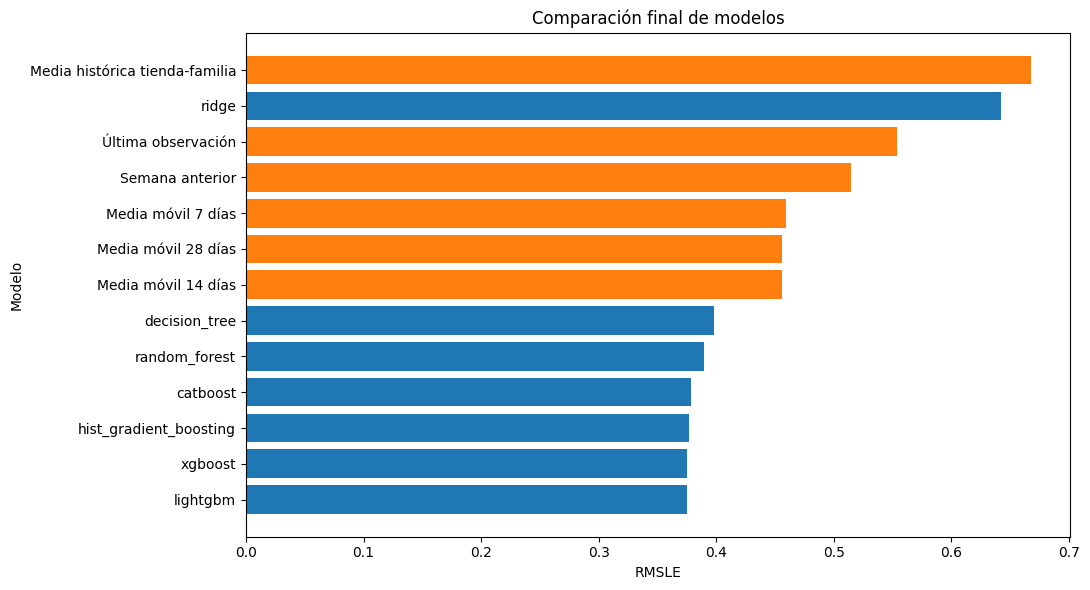

In [49]:
# =============================================================================
# 13. COMPARACIÓN GRÁFICA
# =============================================================================

import matplotlib.pyplot as plt

plot = comparison.sort_values(
    "RMSLE",
    ascending=True,
)

plt.figure(figsize=(11,6))

colors = [
    "tab:blue"
    if category == "Machine Learning"
    else "tab:orange"
    for category in plot["category"]
]

plt.barh(
    plot["model"],
    plot["RMSLE"],
    color=colors,
)

plt.xlabel("RMSLE")
plt.ylabel("Modelo")
plt.title("Comparación final de modelos")

plt.tight_layout()

plt.savefig(
    ML_FIGURES_PATH / "comparacion_final_modelos.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [50]:
# =============================================================================
# 14. RESUMEN FINAL
# =============================================================================

best_baseline = (
    baseline_results
    .sort_values("RMSLE")
    .iloc[0]
)

best_ml = (
    ml_results
    .sort_values("RMSLE")
    .iloc[0]
)

print("=" * 80)

print("MEJOR BASELINE")
print("-" * 80)

print(
    f"{best_baseline['model']} "
    f"(RMSLE = {best_baseline['RMSLE']:.5f})"
)

print()

print("MEJOR MODELO DE MACHINE LEARNING")
print("-" * 80)

print(
    f"{best_ml['model']} "
    f"(RMSLE = {best_ml['RMSLE']:.5f})"
)

print()

improvement = (
    (
        best_baseline["RMSLE"]
        - best_ml["RMSLE"]
    )
    / best_baseline["RMSLE"]
) * 100

print("MEJORA RESPECTO AL MEJOR BASELINE")
print("-" * 80)

print(
    f"{improvement:.2f}%"
)

MEJOR BASELINE
--------------------------------------------------------------------------------
Media móvil 14 días (RMSLE = 0.45599)

MEJOR MODELO DE MACHINE LEARNING
--------------------------------------------------------------------------------
lightgbm (RMSLE = 0.37502)

MEJORA RESPECTO AL MEJOR BASELINE
--------------------------------------------------------------------------------
17.76%


In [51]:
# =============================================================================
# COMPARACIÓN ENTRE EL MEJOR BASELINE Y EL MEJOR MODELO ML
# =============================================================================

rmsle_baseline = best_baseline["RMSLE"]
rmsle_ml = best_ml["RMSLE"]

relative_change = (
    (rmsle_baseline - rmsle_ml)
    / rmsle_baseline
) * 100

print("=" * 80)
print("MEJOR BASELINE")
print("-" * 80)

print(
    f"{best_baseline['model']} "
    f"(RMSLE = {rmsle_baseline:.5f})"
)

print("\nMEJOR MODELO DE MACHINE LEARNING")
print("-" * 80)

print(
    f"{best_ml['model']} "
    f"(RMSLE = {rmsle_ml:.5f})"
)

print("\nCOMPARACIÓN RESPECTO AL MEJOR BASELINE")
print("-" * 80)

if relative_change > 0:
    print(
        f"El modelo {best_ml['model']} mejora el RMSLE del "
        f"baseline en un {relative_change:.2f}%."
    )

elif relative_change < 0:
    deterioration = abs(relative_change)

    print(
        f"El modelo {best_ml['model']} no supera al baseline. "
        f"Su RMSLE es un {deterioration:.2f}% peor."
    )

else:
    print(
        "El modelo de machine learning y el baseline "
        "obtienen el mismo RMSLE."
    )

MEJOR BASELINE
--------------------------------------------------------------------------------
Media móvil 14 días (RMSLE = 0.45599)

MEJOR MODELO DE MACHINE LEARNING
--------------------------------------------------------------------------------
lightgbm (RMSLE = 0.37502)

COMPARACIÓN RESPECTO AL MEJOR BASELINE
--------------------------------------------------------------------------------
El modelo lightgbm mejora el RMSLE del baseline en un 17.76%.


In [ ]:
# =============================================================================
# MODELO GANADOR
# =============================================================================

from pathlib import Path

results_path = (
    PROJECT_ROOT
    / "data"
    / "results"
    / "machine_learning_validation_results.csv"
)

results = pd.read_csv(results_path)

results = results.sort_values(
    by="RMSLE",
    ascending=True,
).reset_index(drop=True)

winner = results.iloc[0]

print("=" * 80)
print("MODELO GANADOR")
print("=" * 80)

print(f"Modelo: {winner['model']}")
print(f"RMSLE : {winner['RMSLE']:.5f}")
print(f"MAE   : {winner['MAE']:.2f}")
print(f"RMSE  : {winner['RMSE']:.2f}")
print(f"Tiempo de entrenamiento: {winner['training_seconds']:.2f} s")

print("\nRanking completo:")
display(
    results[
        [
            "model",
            "RMSLE",
            "MAE",
            "RMSE",
            "training_seconds",
        ]
    ]
)

MODELO GANADOR
Modelo: lightgbm
RMSLE : 0.37502
MAE   : 55.90
RMSE  : 229.00
Tiempo de entrenamiento: 6.19 s

Ranking completo:


,model,RMSLE,MAE,RMSE,training_seconds
0,lightgbm,0.375019,55.897614,228.999420,6.185183
1,xgboost,0.375438,56.188023,231.231674,4.889679
2,hist_gradient_boosting,0.376639,57.323353,239.629562,6.111417
3,catboost,0.378827,58.943275,232.837219,69.853584
4,random_forest,0.389130,69.178596,326.734558,3.458364
5,decision_tree,0.397880,63.146496,252.713272,3.527765
6,ridge,0.642323,192.105118,1181.149170,1.691368


In [ ]:
# =============================================================================
# 6.4. AJUSTE DE HIPERPARÁMETROS DEL MODELO GANADOR
# =============================================================================

from itertools import product
from lightgbm import LGBMRegressor

print("Ajuste de hiperparámetros para LightGBM")
print(f"Entrenamiento: {effective_train_start.date()} - {train_end.date()}")
print(f"Validación: {validation_start.date()} - {validation_end.date()}")
print("El conjunto de test permanece reservado.")

Ajuste de hiperparámetros para LightGBM
Entrenamiento: 2017-03-23 - 2017-06-20
Validación: 2017-06-21 - 2017-07-18
El conjunto de test permanece reservado.


In [ ]:
# =============================================================================
# PREPARACIÓN DE DATOS PARA EL AJUSTE
# =============================================================================

import gc
import numpy as np
import pandas as pd
import time

X_train_tuning = preprocessor.fit_transform(X_train)
X_validation_tuning = preprocessor.transform(X_validation)

X_train_tuning = np.asarray(
    X_train_tuning,
    dtype=np.float32,
)

X_validation_tuning = np.asarray(
    X_validation_tuning,
    dtype=np.float32,
)


y_train_tuning = np.log1p(
    y_train.to_numpy(dtype=np.float32)
)

y_validation_tuning = np.log1p(
    y_validation.to_numpy(dtype=np.float32)
)

print("X_train_tuning:", X_train_tuning.shape)
print("X_validation_tuning:", X_validation_tuning.shape)

X_train_tuning: (160380, 43)
X_validation_tuning: (49896, 43)


In [55]:
# =============================================================================
# ESPACIO DE HIPERPARÁMETROS
# =============================================================================

parameter_grid = {
    "learning_rate": [
        0.03,
        0.05,
    ],

    "num_leaves": [
        31,
        63,
    ],

    "max_depth": [
        8,
        12,
    ],

    "min_child_samples": [
        50,
        100,
    ],
}

combinations = list(
    product(
        parameter_grid["learning_rate"],
        parameter_grid["num_leaves"],
        parameter_grid["max_depth"],
        parameter_grid["min_child_samples"],
    )
)

print(
    f"Número de configuraciones a probar: {len(combinations)}"
)

Número de configuraciones a probar: 16


In [ ]:
# =============================================================================
# BÚSQUEDA MANUAL DE HIPERPARÁMETROS
# =============================================================================

tuning_results = []

for i, (
    learning_rate,
    num_leaves,
    max_depth,
    min_child_samples,
) in enumerate(combinations, start=1):

    print("=" * 80)
    print(
        f"Configuración {i}/{len(combinations)}"
    )

    print(
        f"learning_rate={learning_rate}, "
        f"num_leaves={num_leaves}, "
        f"max_depth={max_depth}, "
        f"min_child_samples={min_child_samples}"
    )

    start_time = time.time()

    tuning_model = LGBMRegressor(
        objective="regression",

        n_estimators=300,

        learning_rate=learning_rate,
        num_leaves=num_leaves,
        max_depth=max_depth,
        min_child_samples=min_child_samples,

        subsample=0.75,
        colsample_bytree=0.75,

        reg_alpha=0.10,
        reg_lambda=1.00,

        max_bin=127,

        n_jobs=1,
        random_state=RANDOM_STATE,
        verbosity=-1,
    )

    tuning_model.fit(
        X_train_tuning,
        y_train_tuning,
    )

    predictions_log = (
        tuning_model.predict(
            X_validation_tuning
        )
    )

    predictions = np.expm1(
        predictions_log
    )

    predictions = np.clip(
        predictions,
        0,
        None,
    )

    metrics = calculate_metrics(
        y_validation,
        predictions,
    )

    elapsed_time = (
        time.time()
        - start_time
    )

    tuning_results.append(
        {
            "learning_rate":
                learning_rate,

            "num_leaves":
                num_leaves,

            "max_depth":
                max_depth,

            "min_child_samples":
                min_child_samples,

            "RMSLE":
                metrics["RMSLE"],

            "MAE":
                metrics["MAE"],

            "RMSE":
                metrics["RMSE"],

            "training_seconds":
                elapsed_time,
        }
    )

    print(
        f"RMSLE = "
        f"{metrics['RMSLE']:.5f}"
    )

    del tuning_model
    del predictions_log
    del predictions

    gc.collect()

Configuración 1/16
learning_rate=0.03, num_leaves=31, max_depth=8, min_child_samples=50


RMSLE = 0.37631
Configuración 2/16
learning_rate=0.03, num_leaves=31, max_depth=8, min_child_samples=100
RMSLE = 0.37599
Configuración 3/16
learning_rate=0.03, num_leaves=31, max_depth=12, min_child_samples=50
RMSLE = 0.37590
Configuración 4/16
learning_rate=0.03, num_leaves=31, max_depth=12, min_child_samples=100
RMSLE = 0.37531
Configuración 5/16
learning_rate=0.03, num_leaves=63, max_depth=8, min_child_samples=50
RMSLE = 0.37499
Configuración 6/16
learning_rate=0.03, num_leaves=63, max_depth=8, min_child_samples=100
RMSLE = 0.37471
Configuración 7/16
learning_rate=0.03, num_leaves=63, max_depth=12, min_child_samples=50
RMSLE = 0.37477
Configuración 8/16
learning_rate=0.03, num_leaves=63, max_depth=12, min_child_samples=100
RMSLE = 0.37428
Configuración 9/16
learning_rate=0.05, num_leaves=31, max_depth=8, min_child_samples=50
RMSLE = 0.37534
Configuración 10/16
learning_rate=0.05, num_leaves=31, max_depth=8, min_child_samples=100
RMSLE = 0.37457
Configuración 11/16
learning_rate=0.05

In [57]:
# =============================================================================
# RESULTADOS DEL AJUSTE
# =============================================================================

tuning_results_df = pd.DataFrame(
    tuning_results
)

tuning_results_df = (
    tuning_results_df
    .sort_values(
        "RMSLE"
    )
    .reset_index(
        drop=True
    )
)

display(
    tuning_results_df
)

best_tuning = (
    tuning_results_df
    .iloc[0]
)

print("=" * 80)
print("MEJOR CONFIGURACIÓN DE LIGHTGBM")
print("=" * 80)

print(
    f"learning_rate: "
    f"{best_tuning['learning_rate']}"
)

print(
    f"num_leaves: "
    f"{int(best_tuning['num_leaves'])}"
)

print(
    f"max_depth: "
    f"{int(best_tuning['max_depth'])}"
)

print(
    f"min_child_samples: "
    f"{int(best_tuning['min_child_samples'])}"
)

print(
    f"RMSLE: "
    f"{best_tuning['RMSLE']:.5f}"
)

print(
    f"MAE: "
    f"{best_tuning['MAE']:.2f}"
)

print(
    f"RMSE: "
    f"{best_tuning['RMSE']:.2f}"
)

,learning_rate,num_leaves,max_depth,min_child_samples,RMSLE,MAE,RMSE,training_seconds
0,0.05,63,12,100,0.374240,56.488723,225.311125,6.038209
1,0.03,63,12,100,0.374285,56.270379,228.133581,7.089589
2,0.05,31,12,100,0.374550,55.614374,223.368527,5.091110
3,0.05,31,8,100,0.374573,55.753627,224.681708,5.148304
4,0.03,63,8,100,0.374712,56.718199,230.706927,7.036353
5,0.03,63,12,50,0.374774,56.490360,230.169746,6.893646
6,0.05,63,8,100,0.374815,55.704398,222.072481,6.202061
7,0.03,63,8,50,0.374990,56.544406,227.655778,6.930723
8,0.05,31,12,50,0.375028,55.668676,227.746897,5.134892
9,0.05,63,12,50,0.375096,56.559080,225.567077,5.760363


MEJOR CONFIGURACIÓN DE LIGHTGBM
learning_rate: 0.05
num_leaves: 63
max_depth: 12
min_child_samples: 100
RMSLE: 0.37424
MAE: 56.49
RMSE: 225.31


In [58]:
# =============================================================================
# COMPARACIÓN: LIGHTGBM ORIGINAL VS AJUSTADO
# =============================================================================

original_lightgbm = (
    ml_results.loc[
        ml_results["model"]
        == "lightgbm"
    ]
    .iloc[0]
)

original_rmsle = (
    original_lightgbm["RMSLE"]
)

tuned_rmsle = (
    best_tuning["RMSLE"]
)

improvement = (
    (
        original_rmsle
        - tuned_rmsle
    )
    / original_rmsle
) * 100


print("=" * 80)
print("COMPARACIÓN DEL AJUSTE")
print("=" * 80)

print(
    f"LightGBM original: "
    f"{original_rmsle:.5f}"
)

print(
    f"LightGBM ajustado: "
    f"{tuned_rmsle:.5f}"
)


if improvement > 0:

    print(
        f"\nEl ajuste mejora "
        f"el RMSLE en "
        f"{improvement:.2f}%."
    )

elif improvement < 0:

    print(
        f"\nEl ajuste no mejora "
        f"la configuración original."
    )

else:

    print(
        "\nAmbas configuraciones "
        "obtienen el mismo RMSLE."
    )

COMPARACIÓN DEL AJUSTE
LightGBM original: 0.37502
LightGBM ajustado: 0.37424

El ajuste mejora el RMSLE en 0.21%.


In [ ]:
# =============================================================================
# 14. EVALUACIÓN FINAL SOBRE EL TEST INTERNO
# =============================================================================

In [ ]:
# =============================================================================
# 14.1. CARGA DEL TEST INTERNO RESERVADO
# =============================================================================

final_train_start = effective_train_start
final_train_end = validation_end

print(
    f"Entrenamiento final: "
    f"{final_train_start.date()} - {final_train_end.date()}"
)

print(
    f"Test interno: "
    f"{test_start.date()} - {test_end.date()}"
)

final_df = pd.read_parquet(
    DATASET_PATH,
    columns=required_columns,
    filters=[
        (
            "date",
            ">=",
            final_train_start,
        ),
        (
            "date",
            "<=",
            test_end,
        ),
    ],
    engine="pyarrow",
)

final_df["date"] = pd.to_datetime(
    final_df["date"]
)

print(
    "Dimensiones cargadas:",
    final_df.shape,
)

Entrenamiento final: 2017-03-23 - 2017-07-18
Test interno: 2017-07-19 - 2017-08-15


Dimensiones cargadas: (260172, 45)


In [61]:
# =============================================================================
# 14.2. CREACIÓN DE TRAIN+VALIDATION Y TEST
# =============================================================================

final_train_mask = (
    (final_df["date"] >= final_train_start)
    & (final_df["date"] <= final_train_end)
)

final_test_mask = (
    (final_df["date"] >= test_start)
    & (final_df["date"] <= test_end)
)


X_final_train = (
    final_df.loc[
        final_train_mask,
        feature_columns,
    ]
    .reset_index(drop=True)
    .copy()
)

y_final_train = (
    final_df.loc[
        final_train_mask,
        TARGET,
    ]
    .reset_index(drop=True)
    .astype(np.float32)
)


X_test = (
    final_df.loc[
        final_test_mask,
        feature_columns,
    ]
    .reset_index(drop=True)
    .copy()
)

y_test = (
    final_df.loc[
        final_test_mask,
        TARGET,
    ]
    .reset_index(drop=True)
    .astype(np.float32)
)


test_identifiers = (
    final_df.loc[
        final_test_mask,
        [
            "date",
            "store_nbr",
            "family",
            TARGET,
        ],
    ]
    .reset_index(drop=True)
    .copy()
)


print(
    "Train + validation:",
    X_final_train.shape,
)

print(
    "Test:",
    X_test.shape,
)


del final_df
del final_train_mask
del final_test_mask

gc.collect()

Train + validation: (210276, 43)
Test: (49896, 43)


0

In [62]:
# =============================================================================
# 14.3. PREPROCESAMIENTO FINAL
# =============================================================================

X_final_train_encoded = (
    preprocessor.fit_transform(
        X_final_train
    )
)

X_test_encoded = (
    preprocessor.transform(
        X_test
    )
)


X_final_train_encoded = np.asarray(
    X_final_train_encoded,
    dtype=np.float32,
)

X_test_encoded = np.asarray(
    X_test_encoded,
    dtype=np.float32,
)


y_final_train_model = np.log1p(
    y_final_train.to_numpy(
        dtype=np.float32
    )
)


print(
    "Train final codificado:",
    X_final_train_encoded.shape,
)

print(
    "Test codificado:",
    X_test_encoded.shape,
)

Train final codificado: (210276, 43)
Test codificado: (49896, 43)


In [ ]:
# =============================================================================
# 14.4. ENTRENAMIENTO DEL LIGHTGBM DEFINITIVO
# =============================================================================

from lightgbm import LGBMRegressor


final_model = LGBMRegressor(
    objective="regression",

    n_estimators=300,

    learning_rate=0.05,
    num_leaves=63,
    max_depth=12,
    min_child_samples=100,

    subsample=0.75,
    colsample_bytree=0.75,
    reg_alpha=0.10,
    reg_lambda=1.00,
    max_bin=127,

    n_jobs=1,
    random_state=RANDOM_STATE,
    verbosity=-1,
)


final_training_start = time.time()


final_model.fit(
    X_final_train_encoded,
    y_final_train_model,
)


final_training_seconds = (
    time.time()
    - final_training_start
)


print(
    f"Modelo final entrenado en "
    f"{final_training_seconds:.2f} segundos."
)

Modelo final entrenado en 6.74 segundos.


In [64]:
# =============================================================================
# 14.5. EVALUACIÓN FINAL EN TEST
# =============================================================================

test_predictions = np.expm1(
    final_model.predict(
        X_test_encoded
    )
)

test_predictions = np.clip(
    test_predictions,
    0,
    None,
).astype(np.float32)


test_metrics = calculate_metrics(
    y_test,
    test_predictions,
)


# WAPE
wape_denominator = (
    np.abs(
        y_test.to_numpy()
    ).sum()
)

if wape_denominator > 0:

    test_wape = (
        np.abs(
            y_test.to_numpy()
            - test_predictions
        ).sum()
        / wape_denominator
    ) * 100

else:

    test_wape = np.nan


print("=" * 80)
print("EVALUACIÓN FINAL SOBRE TEST INTERNO")
print("=" * 80)

print(
    f"RMSLE: "
    f"{test_metrics['RMSLE']:.5f}"
)

print(
    f"MAE: "
    f"{test_metrics['MAE']:.2f}"
)

print(
    f"RMSE: "
    f"{test_metrics['RMSE']:.2f}"
)

print(
    f"WAPE: "
    f"{test_wape:.2f}%"
)

EVALUACIÓN FINAL SOBRE TEST INTERNO
RMSLE: 0.38644
MAE: 62.40
RMSE: 224.84
WAPE: 13.28%


In [65]:
# =============================================================================
# 14.6. GUARDADO DEL MODELO Y PREDICCIONES FINALES
# =============================================================================

final_model_path = (
    MODELS_PATH
    / "lightgbm_final.joblib"
)


joblib.dump(
    {
        "preprocessor": preprocessor,
        "model": final_model,
        "feature_columns": feature_columns,
        "parameters": {
            "n_estimators": 300,
            "learning_rate": 0.05,
            "num_leaves": 63,
            "max_depth": 12,
            "min_child_samples": 100,
            "subsample": 0.75,
            "colsample_bytree": 0.75,
            "reg_alpha": 0.10,
            "reg_lambda": 1.00,
            "max_bin": 127,
            "target_transform": "log1p",
        },
    },
    final_model_path,
)


test_predictions_df = (
    test_identifiers.copy()
)

test_predictions_df[
    "prediction"
] = test_predictions


test_predictions_path = (
    RESULTS_DATA_PATH
    / "predictions_lightgbm_final_test.parquet"
)


test_predictions_df.to_parquet(
    test_predictions_path,
    index=False,
)


final_results = pd.DataFrame(
    [
        {
            "model": "lightgbm_tuned",
            "partition": "test",
            "RMSLE": test_metrics["RMSLE"],
            "MAE": test_metrics["MAE"],
            "RMSE": test_metrics["RMSE"],
            "WAPE": test_wape,
            "training_seconds":
                final_training_seconds,
            "train_start":
                final_train_start.date().isoformat(),
            "train_end":
                final_train_end.date().isoformat(),
            "test_start":
                test_start.date().isoformat(),
            "test_end":
                test_end.date().isoformat(),
        }
    ]
)


final_results_path = (
    RESULTS_DATA_PATH
    / "final_test_results.csv"
)


final_results.to_csv(
    final_results_path,
    index=False,
)


display(final_results)

print(
    "\nModelo final:",
    final_model_path,
)

print(
    "Predicciones de test:",
    test_predictions_path,
)

print(
    "Resultados:",
    final_results_path,
)

,model,partition,RMSLE,MAE,RMSE,WAPE,training_seconds,train_start,train_end,test_start,test_end
0,lightgbm_tuned,test,0.386444,62.399788,224.8414,13.284624,6.735903,2017-03-23,2017-07-18,2017-07-19,2017-08-15



Modelo final: ../models/lightgbm_final.joblib
Predicciones de test: ../data/results/predictions_lightgbm_final_test.parquet
Resultados: ../data/results/final_test_results.csv


In [66]:
# =============================================================================
# 15. LIBERACIÓN FINAL DE MEMORIA
# =============================================================================

objects_to_delete = [
    "model",
    "predictions",
    "X_train",
    "X_validation",
    "y_train",
    "y_validation",
    "validation_identifiers",
    "X_train_encoded",
    "X_validation_encoded",
    "y_train_model",
    "y_validation_model",
]

for object_name in objects_to_delete:
    if object_name in globals():
        del globals()[object_name]

gc.collect()

print(f"Memoria final: {process_memory_gb():.2f} GB")

Memoria final: 0.72 GB
